# Minimal example

This notebook provides a minimal example to go from an edepsim event $\rightarrow$ final stitched waveform.

**Pipeline:**
1. Load edepsim data & compute light yield
2. TOF sampling (photon library)
3. Stochastic delays (scintillation, TPB, PMT TTS)
4. Histogramming into `Waveform` or `SlicedWaveform`
5. FFT convolution with detector impulse response

In [1]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '0'
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false" # otherwise allocates 75% GB vram
import sys; sys.path.insert(0, "../jaxtpc")
import sys; sys.path.insert(0, "..")
import torch

# 1. Configure simulator

In [10]:
from goop import (
    OpticalSimConfig,
    OpticalSimulator,
    Waveform,
    SlicedWaveform,
)
from goop.kernels import SERKernel, RLCKernel
from goop.delays import ScintillationBiexponentialDelay, TTSDelay, TPBTriexponentialDelay
from goop.noise import DarkNoise
from goop.digitize import DigitizationConfig
from goop.sampler import create_default_tof_sampler

config = OpticalSimConfig(
    tof_sampler=create_default_tof_sampler(lazy=True), # PCA sampler
    delays=[
        ScintillationBiexponentialDelay(singlet_fraction=0.3, tau_singlet_ns=6.0, tau_triplet_ns=1300.0),
        TPBTriexponentialDelay(),
        TTSDelay(fwhm_ns=2.4, apply_transit_time=False), # only adds +/- sigma, not mean +/- sigma
    ],
    tick_ns=1.0, # 1 GHz
    aux_photon_sources=[DarkNoise(rate_hz=2000.0)],
    kernel=SERKernel(device=torch.device("cuda")),
    # digitization=DigitizationConfig(n_bits=14, pedestal=1500.0),
    gain=1.0 # PMT-independent gaian; is applied in the SERKernel. for RLCKernel, set to e.g. -45
)
sim = OpticalSimulator(config)

# 2. Load data, compute light yield


Note that loading in data / creating data inputs for the simulator are done outside the simulator. This is because it it not obvious how we will interact with JAXTPC. As of now, the simulator takes in

1. step positions
2. step times
3. number of photons per step

In [5]:
from tools.loader import ParticleStepExtractor, DepositData
import jax.numpy as jnp
import torch

filepath = '/sdf/home/y/youngsam/sw/dune/sirentv/data/out.h5'
LIGHT_YIELD = 20_000

def derive_inputs(step_data):
    """No data structure for these inputs yet"""

    # compute light yield & grab times
    positions_mm = jnp.asarray(step_data.get('position', jnp.empty((0, 3))), dtype=jnp.float32)
    n = positions_mm.shape[0]
    de = jnp.asarray(step_data.get('de', jnp.zeros((n,))), dtype=jnp.float32)
    t_step = step_data.get('t', jnp.zeros((n,)))
    # compute number of photons per step
    photons_step = jnp.ceil(de * LIGHT_YIELD).astype(jnp.int32)
    # convert to torch on the GPU
    pos_torch = torch.from_dlpack(positions_mm)
    nph_torch = torch.from_dlpack(photons_step)
    ts_torch = torch.from_dlpack(t_step)
    return pos_torch, nph_torch, ts_torch

EVENT_ID = 0
with ParticleStepExtractor(filepath, verbose=True) as extractor:
    step_data = extractor.extract_step_arrays(EVENT_ID)
    pos_torch, nph_torch, ts_torch = derive_inputs(step_data)


Loaded file: /sdf/home/y/youngsam/sw/dune/sirentv/data/out.h5
Step path: pstep/lar_vol
Particle path: particle/geant4
Association path: ass/particle_pstep_lar_vol


E0323 13:37:31.167264  473678 numa_hwloc.cc:121] Call to hwloc_set_cpubind() failed: Invalid argument [22]
E0323 13:37:31.167334  473679 numa_hwloc.cc:121] Call to hwloc_set_cpubind() failed: Invalid argument [22]
E0323 13:37:31.167385  473680 numa_hwloc.cc:121] Call to hwloc_set_cpubind() failed: Invalid argument [22]


Skipping string field: proc_name_start
Skipping string field: proc_name_end


# 3. Run simulator

You can create the whole (original) waveform:

In [11]:
# stitched=False returns full original waveform
orig_wvfm = sim.simulate(pos_torch, nph_torch, ts_torch, stitched=False, subtract_t0=False)
orig_wvfm

Waveform(data=tensor([[-1.3411e-06, -2.8610e-06, -9.1642e-07,  ...,  9.5367e-07,
          4.7684e-07,  0.0000e+00],
        [-8.0094e-07,  1.2610e-06, -8.0932e-07,  ...,  0.0000e+00,
          0.0000e+00,  1.9073e-06],
        [ 1.3877e-06, -7.4506e-09,  5.6811e-07,  ...,  0.0000e+00,
          0.0000e+00, -3.8147e-06],
        ...,
        [-8.2403e-06, -1.7181e-05, -1.1697e-05,  ..., -8.3447e-07,
          7.6294e-06,  3.0994e-06],
        [-4.3213e-06, -6.2883e-06, -5.5879e-07,  ..., -4.2915e-06,
         -4.7684e-07, -2.3842e-06],
        [ 7.8902e-06,  7.2643e-06, -2.8014e-06,  ..., -3.4571e-06,
         -1.6689e-06, -1.6689e-06]], device='cuda:0'), t0=-1721636.0, tick_ns=1.0, n_channels=162)

Or, you can create the "stitched" waveform with dead space removed. This is done without materializing the huge 2D distribution above, so is much more memory efficient.

Note this is done per channel, so there are a set of active regions for each channel.

You can do this with the full TOFSampler library (25GB) read in with `lazy=False`. But you can't do this with the full waveform simulator.

In [12]:
# stitched = True returns the compressed waveform. this is what we save!
stitched_wvfm: SlicedWaveform = sim.simulate(pos_torch, nph_torch, ts_torch, stitched=True)
stitched_wvfm

SlicedWaveform(adc=tensor([ 4.5449e-07, -2.0905e+01, -2.5000e+01,  ...,  5.3525e-05,
         5.2571e-05,  5.2989e-05], device='cuda:0'), offsets=tensor([       0,    17208,    29207,  ..., 54496471, 54512329, 54522517],
       device='cuda:0'), t0_ns=tensor([-1721555., -1437006., -1388163.,  ...,  1029406.,  1048163.,
         1597155.], device='cuda:0'), pmt_id=tensor([  0,   0,   0,  ..., 161, 161, 161], device='cuda:0'), tick_ns=1.0, n_channels=162, n_bins=None)

You can reconstruct the dense 2D waveform via `deslice()`.

In [13]:
recon_wvfm: Waveform = stitched_wvfm.deslice()  #  reconstructs the full waveform
recon_wvfm

Waveform(data=tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]], device='cuda:0'), t0=-1721635.0, tick_ns=1.0, n_channels=162)

In [16]:
recon_wvfm.data.max(), recon_wvfm.data.min()

(tensor(660.6200, device='cuda:0'), tensor(-15651.1006, device='cuda:0'))

Plotting out the full waveform

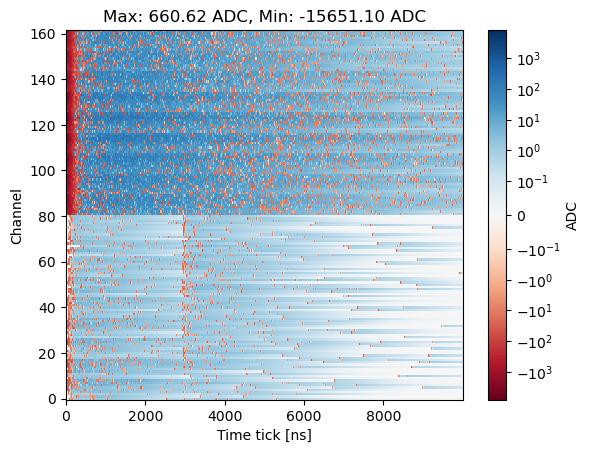

In [19]:
import matplotlib.pyplot as plt
from matplotlib.colors import SymLogNorm
import numpy as np

data = recon_wvfm.data[:,:10_000].cpu().numpy()
vmax = np.max(abs(data))
plt.imshow(
    data,
    aspect='auto',
    interpolation='none',
    origin='lower',
    norm=SymLogNorm(linthresh=1e-1, linscale=1.0, vmin=-vmax, vmax=vmax),
    cmap='RdBu',
)
plt.xlabel('Time tick [ns]')
plt.ylabel('Channel')
plt.colorbar(label="ADC")
plt.title("Max: {:.2f} ADC, Min: {:.2f} ADC".format(recon_wvfm.data.max(), recon_wvfm.data.min()))
plt.show()